# 第一讲：视觉学习总览与 PyTorch 基础

这份 notebook 按一条连续主线展开：

**先确认视觉任务在处理什么 -> 再拆开一次训练 -> 再说明梯度如何被自动计算 -> 再把这些概念装进 PyTorch 接口 -> 最后走到一个真实图像分类 pipeline**

贯穿全文的核心问题只有一个：

> **参数为什么会朝更好的方向更新？**

这一讲的重点不是堆公式，而是把“数据、模型、损失、梯度、优化器、评估”之间的因果关系讲顺。

## 本节课学习目标

1. 把整门课会反复出现的训练主线先建立起来。
2. 看清视觉任务里的输入、标签、模型输出和评估对象分别是什么。
3. 用最小例子理解前向传播、损失、梯度、学习率和参数更新之间的关系。
4. 理解 PyTorch 中 `Tensor`、`autograd`、`nn.Module`、`optimizer` 的分工。
5. 能顺着一条统一逻辑读懂一个最基本的图像分类训练脚本。

## 课程地图

<img src="images/lesson1_intro/course_map.png" width="950">

> 第一讲先搭共同骨架。后面讲 CNN、ViT、自监督、3D、生成、多模态时，变化的主要是表征方式和模型结构；训练闭环本身并没有变。

## 这份 notebook 的展开顺序

- Part 1：先确认视觉任务里的输入、输出和评估对象。
- Part 2：用一个最小例子拆开一次训练步骤。
- Part 3：解释梯度是什么，以及 autograd 为什么重要。
- Part 4：把这些概念装进 PyTorch 的常用接口。
- Part 5：把 toy 例子扩展成一个真实图像分类 pipeline。
- Part 6：用 MLP 的局限自然过渡到 CNN。


In [40]:
# ------------------------------
# 这段代码做什么：
# 1. 导入本节课要用到的依赖
# 2. 固定随机种子，保证课堂演示更稳定
# 3. 自动选择运行设备（CPU / GPU）
# ------------------------------

from pathlib import Path
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import datasets, transforms

plt.style.use('seaborn-v0_8-whitegrid')
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device =', device)

device = cpu


# Part 1. 先看数据：视觉任务到底在处理什么？

先不急着讲模型，先把任务对象看清楚。

对于最基本的图像分类任务，至少要先回答三个问题：

- 输入是什么：图像像素张量。
- 输出是什么：类别标签。
- 评价依据是什么：预测是否正确，损失是否下降。

这一部分的作用，是先把“模型到底在处理什么”说清楚。只有输入和输出边界清楚了，后面讲训练闭环时才不会飘在空中。

In [41]:
# ------------------------------
# 这段代码做什么：
# 1. 读取 FashionMNIST 原始数据
# 2. 查看数据规模、类别名和单张图像尺寸
# 3. 对应 Part 1：先确认任务在处理什么对象
# ------------------------------

data_root = Path.home() / 'data' / 'FMNIST'
train_raw = datasets.FashionMNIST(data_root, train=True, download=True)
val_raw = datasets.FashionMNIST(data_root, train=False, download=True)

print('训练集大小:', len(train_raw))
print('验证集大小:', len(val_raw))
print('类别名:', train_raw.classes)
print('第一张图像尺寸:', train_raw.data[0].shape)

训练集大小: 60000
验证集大小: 10000
类别名: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
第一张图像尺寸: torch.Size([28, 28])


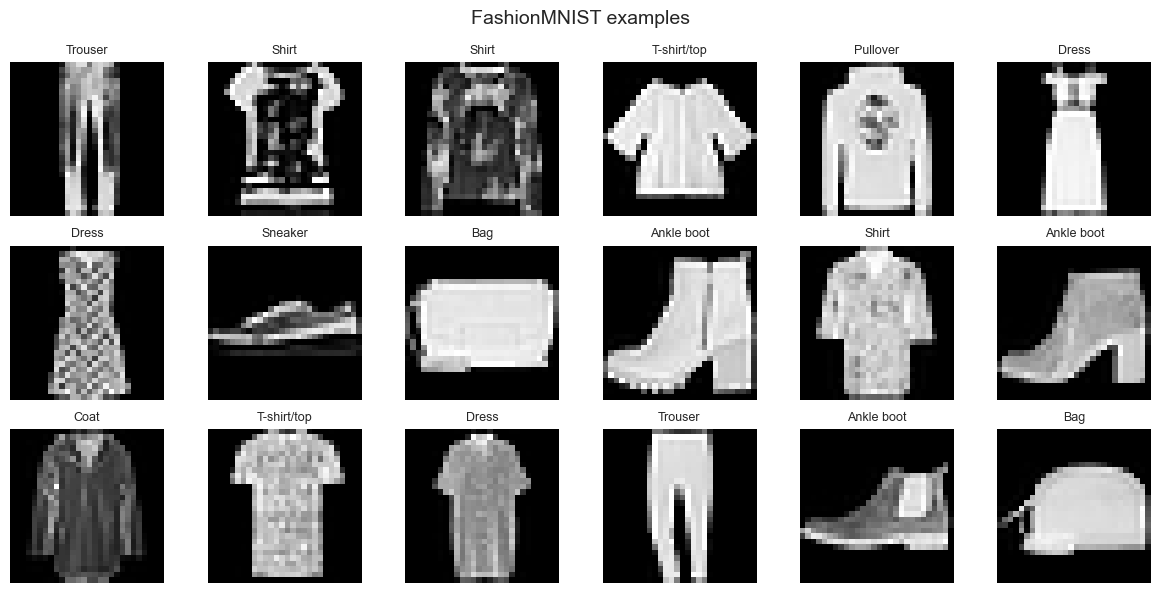

In [42]:
# ------------------------------
# 这段代码做什么：
# 1. 随机展示若干原始样本
# 2. 让图像、标签和类别名先建立直观对应
# ------------------------------

R, C = 3, 6
fig, axes = plt.subplots(R, C, figsize=(12, 6))
for ax in axes.flat:
    idx = np.random.randint(len(train_raw))
    image, label = train_raw[idx]
    ax.imshow(image, cmap='gray')
    ax.set_title(train_raw.classes[label], fontsize=9)
    ax.axis('off')
plt.suptitle('FashionMNIST examples', fontsize=14)
plt.tight_layout()
plt.show()

### 这一部分先收束一下

到这里先收住四件事：

- 图像本质上就是一个数值数组。
- FashionMNIST 的单张图像大小是 `28 x 28`，也就是 784 个像素值。
- 标签是离散类别，不是连续数值。
- 评估模型时，不只是看图像长什么样，还要看预测类别和真实标签是否一致。

可以先停一下，想一个问题：

> 如果已经知道输入是图像、输出是标签，接下来还差哪一步，模型才能“越学越好”？

下一部分就回答这个问题：参数如何在误差驱动下更新。

# Part 2. 从一个极简模型理解训练闭环

Part 1 解决的是“训练在处理什么对象”；Part 2 要解决的是“参数为什么会越来越合适”。

目标不是推导复杂公式，而是把训练这件事真正拆开看清楚。

训练过程通常会先被概括成四步：

1. 用当前参数做一次预测。
2. 计算预测和真值之间的误差。
3. 计算误差对参数的梯度。
4. 沿着能降低误差的方向更新参数。

但如果要在 PyTorch 里真正落地，通常要写成 **五个动作**，因为还要显式清理旧梯度。

## 先把“训练”写成真正会执行的五行

先把最常见的一次训练 step 写出来：

```python
pred = model(x)
loss = loss_fn(pred, y)
optimizer.zero_grad()
loss.backward()
optimizer.step()
```

这五行里每一行做的事情并不一样：

1. `pred = model(x)`：只是在用**当前参数**做前向计算，参数本身还没有变。
2. `loss = loss_fn(pred, y)`：把一个 batch 的预测误差压缩成一个**标量目标**，后面才能围绕这个目标求梯度。
3. `optimizer.zero_grad()`：清掉上一步残留的梯度。PyTorch 默认会把梯度**累加**起来，所以这一步很重要。
4. `loss.backward()`：根据当前 loss 计算每个参数的梯度，并把结果写进 `param.grad`。
5. `optimizer.step()`：优化器读取 `param.grad`，真正修改参数值。

可以先判断两个问题：

- `model(x)` 执行完以后，权重会不会立刻变化？
- `backward()` 和 `step()` 到底谁负责改参数？

> 这里最容易混淆的一点是：**`backward()` 负责“算梯度”，`step()` 才负责“改参数”。**

## 用一个只含单个样本的例子，把一次训练彻底拆开

上一格只是先把训练模板写出来；这一格开始把每一行对应到可见的数值上。

下面故意用一个最小例子：

- 输入只有一个数 `x = 2`
- 目标只有一个数 `y = 6`
- 模型只有一个线性层：`y_hat = wx + b`

这样做的好处是，每一步的中间量都能直接打印出来，不会被复杂网络结构分散注意力。

In [61]:
# ------------------------------
# 这段代码做什么：
# 1. 构造一个只有单个样本的最小例子
# 2. 打印 forward / backward / step 前后的关键量
# 3. 把一次训练 step 完整拆开
# ------------------------------
x_demo = torch.tensor([[2.0]])
y_demo = torch.tensor([[6.0]])

demo_layer = nn.Linear(1, 1)
with torch.no_grad():
    demo_layer.weight.fill_(0.5)
    demo_layer.bias.fill_(0.0)

demo_loss_fn = nn.MSELoss()
demo_opt = torch.optim.SGD(demo_layer.parameters(), lr=0.1)

# 先看参数的初始值。
print('初始参数:')
print('weight =', demo_layer.weight.item(), 'bias =', demo_layer.bias.item())

# 第 1 步：只做前向传播，参数此时还没有更新。
pred_before = demo_layer(x_demo)
loss_before = demo_loss_fn(pred_before, y_demo)
print('\n1) 前向传播之后:')
print('pred =', pred_before.item())
print('loss =', loss_before.item())

# 第 2 步：先清梯度，再反向传播，把梯度写进 param.grad。
demo_opt.zero_grad()
loss_before.backward()

print('\n2) backward 之后，梯度被写入 param.grad:')
for name, param in demo_layer.named_parameters():
    print(f'{name}: value={param.item():.4f}, grad={param.grad.item():.4f}')

# 第 3 步：优化器真正读取梯度并更新参数。
demo_opt.step()

# 更新完成后，再做一次前向传播，看看预测和 loss 是否发生变化。
pred_after = demo_layer(x_demo)
loss_after = demo_loss_fn(pred_after, y_demo)
print('\n3) step 之后，参数真正发生更新:')
print('weight =', demo_layer.weight.item(), 'bias =', demo_layer.bias.item())
print('new pred =', pred_after.item())
print('new loss =', loss_after.item())

初始参数:
weight = 0.5 bias = 0.0

1) 前向传播之后:
pred = 1.0
loss = 25.0

2) backward 之后，梯度被写入 param.grad:
weight: value=0.5000, grad=-20.0000
bias: value=0.0000, grad=-10.0000

3) step 之后，参数真正发生更新:
weight = 2.5 bias = 1.0
new pred = 6.0
new loss = 0.0


### 这一格里最值得停下来强调的点

- `pred` 和 `loss` 都只是“算出来”，不会自动改参数。
- `backward()` 的结果不是更新权重，而是把梯度写到 `weight.grad`、`bias.grad` 里。
- `step()` 才是根据公式 `新参数 = 旧参数 - 学习率 × 梯度` 去更新参数。
- 如果忘了 `zero_grad()`，下一次 `backward()` 会把新梯度累加到旧梯度上。
- 上面这个例子只看了一个样本和一次更新；真实训练是对一个 batch、很多轮重复做同样的事情。

到这里，forward / loss / backward / step / zero_grad 的分工已经可以分开看清。下一步自然要问：如果这个过程重复很多次，步子应该走多大？

## 从一次更新走向很多次更新：学习率的作用

上面只看清了一次 `step`。但真正训练神经网络时，参数会更新很多次。

这时新的问题就出现了：

- 如果每次都只走一点，会不会太慢？
- 如果每次都走很大一步，会不会直接走过头？

这就是学习率要解决的问题。

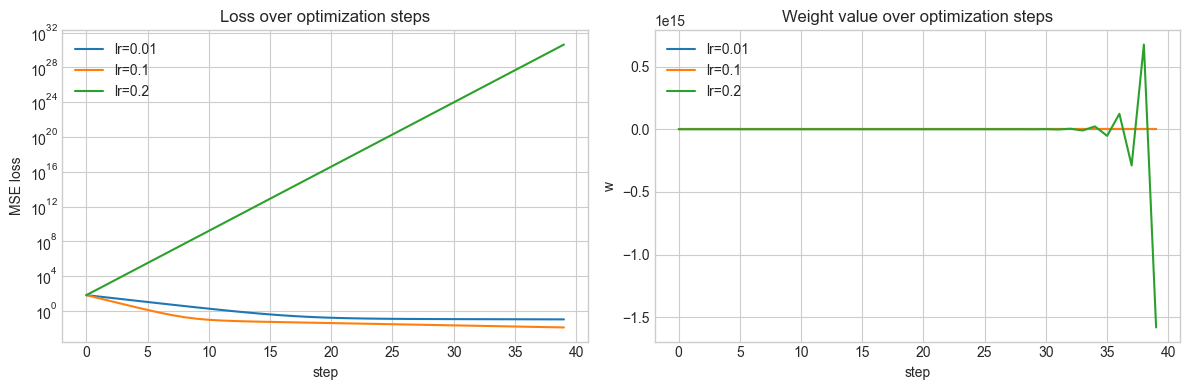

In [62]:
# ------------------------------
# 这段代码做什么：
# 1. 手写一个最简单的梯度下降过程
# 2. 比较不同学习率下 loss 和参数轨迹的变化
# 3. 观察“步子太小 / 合适 / 过大”的区别
# ------------------------------

x = np.array([1, 2, 3, 4], dtype=np.float32)
y = 3 * x


def run_gradient_descent(lr, steps=40):
    # 用最基础的公式手写一遍梯度下降，便于观察学习率的作用。
    w, b = 0.0, 0.0
    history = {'loss': [], 'w': [], 'b': []}
    for _ in range(steps):
        y_hat = w * x + b
        loss = np.mean((y_hat - y) ** 2)
        grad_w = np.mean(2 * (y_hat - y) * x)
        grad_b = np.mean(2 * (y_hat - y))
        w -= lr * grad_w
        b -= lr * grad_b
        history['loss'].append(float(loss))
        history['w'].append(float(w))
        history['b'].append(float(b))
    return history

histories = {
    0.01: run_gradient_descent(0.01),
    0.1: run_gradient_descent(0.1),
    0.2: run_gradient_descent(0.2),
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for lr, hist in histories.items():
    axes[0].plot(hist['loss'], label=f'lr={lr}')
    axes[1].plot(hist['w'], label=f'lr={lr}')
axes[0].set_title('Loss over optimization steps')
axes[0].set_xlabel('step')
axes[0].set_ylabel('MSE loss')
axes[0].set_yscale('log')
axes[1].set_title('Weight value over optimization steps')
axes[1].set_xlabel('step')
axes[1].set_ylabel('w')
axes[0].legend()
axes[1].legend()
plt.tight_layout()
plt.show()

### 这一段可以怎么观察

- `lr=0.01`：能学，但比较慢。
- `lr=0.1`：通常更合适，下降明显。
- `lr=0.2`：可能开始抖动，甚至不稳定。

可以先看两条曲线：

- loss 曲线在不在持续下降？
- 参数曲线是不是朝正确方向靠近，但又没有来回震荡得太厉害？

> 学习率不是“越大越快越好”，而是“步子要足够大，但不能大到走过头”。

# Part 3. 为什么 PyTorch 重要：自动求导

Part 2 已经说明了一次更新里有哪些动作。现在还差一个关键问题：

> **这些梯度到底是怎么得到的？**

前面手动推梯度，是为了把梯度的含义讲清楚；但只要网络一深、参数一多，手推很快就不可行了。

下一部分的关键转折就在这里：

**把计算图和梯度传播交给框架处理。**

## 梯度到底是什么？

如果把损失记作 `L`，把某个参数记作 `w`，那么梯度 `∂L/∂w` 表示：

> **当参数 `w` 轻微变化一点点时，损失 `L` 会朝哪个方向变化、变化得有多快。**

可以把它理解成“损失函数在当前位置的局部斜率”或“局部敏感度”。

### 梯度里最重要的三层信息

1. **符号（正负）**
   - `∂L/∂w > 0`：说明 `w` 再增大，会让 loss 变大，所以更新时通常要把 `w` 往小调。
   - `∂L/∂w < 0`：说明 `w` 再增大，会让 loss 变小，所以更新时通常要把 `w` 往大调。

2. **大小（绝对值）**
   - 绝对值大：loss 对这个参数很敏感，动一点影响就很大。
   - 绝对值小：当前位置比较平，动一点影响不大。

3. **多参数情形下的方向**
   - 神经网络里不只有一个参数，而是一大堆参数 `θ`。
   - 这时梯度不再是单个数，而是一个向量 `∇_θ L`。
   - 它指向 **loss 上升最快** 的方向，所以通常沿着 **负梯度方向** 更新参数，来让 loss 下降。

## 梯度有什么用？

梯度的作用，是把一句模糊的话：

- “模型现在预测得不好”

变成一句可执行的话：

- “具体到每个参数，现在应该往哪边改、改多大”

没有梯度时，优化器就不知道：

- 到底该改哪个参数
- 应该把它调大还是调小
- 哪些参数更重要，哪些参数暂时不敏感

所以梯度本质上是在提供一种 **局部导航信号**。优化器拿到这个信号以后，才能真正更新参数。

<img src="images/lesson1_intro/gradient_on_loss_curve.png" width="900">

### 先用一维情况建立直觉

对于一维参数 `w`，梯度就是损失曲线在当前点的斜率：

- 左边的点梯度是负的：说明把 `w` 往右调，loss 会下降。
- 右边的点梯度是正的：说明把 `w` 往左调，loss 会下降。
- 越靠近最低点，梯度越接近 0：说明已经接近局部最优。

> 一句话：**梯度告诉我们“当前这一步往哪走更可能变好”。**


In [45]:
# ------------------------------
# 这段代码做什么：
# 1. 用一维损失函数直接观察梯度的正负号和大小
# 2. 把梯度符号和“参数该往哪边调”对应起来
# ------------------------------
# 用一个一维损失函数，直接看梯度的正负号和大小
w_points = [0.5, 2.0, 4.5]
for w0 in w_points:
    w = torch.tensor(w0, requires_grad=True)
    loss = (w - 3) ** 2
    loss.backward()
    grad = w.grad.item()
    suggested_direction = '增大 w' if grad < 0 else '减小 w' if grad > 0 else '保持不动'
    print(f'w = {w0:>4.1f}, loss = {loss.item():>4.2f}, grad = {grad:>5.2f}, 对应更新方向: {suggested_direction}')

w =  0.5, loss = 6.25, grad = -5.00, 对应更新方向: 增大 w
w =  2.0, loss = 1.00, grad = -2.00, 对应更新方向: 增大 w
w =  4.5, loss = 2.25, grad =  3.00, 对应更新方向: 减小 w


### 这段输出说明什么？

- 当 `w=0.5` 时，梯度是负的，说明现在参数偏小了，往大调会更好。
- 当 `w=4.5` 时，梯度是正的，说明现在参数偏大了，往小调会更好。
- 当参数靠近最优点 `w=3` 时，梯度会越来越接近 0，说明“局部上已经没什么可改的了”。

这就是为什么优化器经常写成：

```python
w = w - lr * grad
```

因为：

- `grad > 0` 时，减掉它，参数就会变小
- `grad < 0` 时，减掉它，参数就会变大

这恰好对应了“沿负梯度方向下降”。

可以先停一下，想一个问题：

> 如果参数不再是一个数，而是一整个矩阵，梯度会变成什么样？

下面这个张量例子就回答这个问题。

In [46]:
# ------------------------------
# 这段代码做什么：
# 1. 验证张量求导时，梯度会保持与原张量相同的形状
# 2. 用一个可手算的例子检查 autograd 的结果是否正确
# ------------------------------

# 这个例子不是在训练神经网络，而是在验证 autograd 对张量求导的基本行为
A = torch.tensor([[2.0, -1.0], [1.0, 1.0]], requires_grad=True)
out = A.pow(2).sum()
expected_grad = 2 * A.detach()
out.backward()

print('这个例子要说明：out = sum(A^2) 时，理论梯度应该是 2*A')
print('\nA =')
print(A)
print('\nout =', out.item())
print('\n理论梯度 2*A =')
print(expected_grad)
print('\nPyTorch 反向传播得到的 A.grad =')
print(A.grad)
print('\n理论结果和 autograd 是否一致:', torch.allclose(A.grad, expected_grad))

这个例子要说明：out = sum(A^2) 时，理论梯度应该是 2*A

A =
tensor([[ 2., -1.],
        [ 1.,  1.]], requires_grad=True)

out = 7.0

理论梯度 2*A =
tensor([[ 4., -2.],
        [ 2.,  2.]])

PyTorch 反向传播得到的 A.grad =
tensor([[ 4., -2.],
        [ 2.,  2.]])

理论结果和 autograd 是否一致: True


In [47]:
# ------------------------------
# 这段代码做什么：
# 1. 构造一个更接近神经网络的多层计算图
# 2. 观察反向传播后，不同参数张量的梯度 shape
# ------------------------------

# 更贴近神经网络的一个例子：线性层 + 激活 + 损失
x_t = torch.tensor([[1.0, 1.0]])
y_t = torch.tensor([[0.0]])
W1 = torch.randn(2, 3, requires_grad=True)
b1 = torch.zeros(3, requires_grad=True)
W2 = torch.randn(3, 1, requires_grad=True)
b2 = torch.zeros(1, requires_grad=True)

# 前向传播：输入先过第一层，再经过激活函数，最后得到预测值。
hidden = torch.sigmoid(x_t @ W1 + b1)
pred = hidden @ W2 + b2
loss = ((pred - y_t) ** 2).mean()
# 反向传播：PyTorch 会沿着计算图自动把梯度传回各个参数。
loss.backward()

print('loss =', loss.detach().item())
print('W1.grad shape =', tuple(W1.grad.shape))
print('W2.grad shape =', tuple(W2.grad.shape))

loss = 0.325880229473114
W1.grad shape = (2, 3)
W2.grad shape = (3, 1)


<img src="images/lesson1_intro/training_loop.png" width="950">

### 这一页是整节课的中心图

后续无论是 CNN、Transformer 系视觉模型、NeRF 还是 Diffusion，训练时都离不开这条主线。

<img src="images/lesson1_intro/one_training_step_detail.png" width="980">

### 到这里可以先把逻辑收束成一句话

- loss 只告诉“现在好不好”，但不会告诉“下一步怎么改”。
- gradient 把“现在不好”翻译成“每个参数应该往哪边调、调多少”。
- optimizer 不是凭空更新参数，而是根据 gradient 这个局部信号更新参数。

既然 autograd 已经能把 `grad` 算出来，下一部分就把这些对象正式装进 PyTorch 的接口里。

# Part 4. 用 PyTorch 搭一个最小神经网络

Part 3 已经解释了梯度和 autograd 的角色。现在把这些概念收进工程接口：

- `Tensor`：存数据和参数。
- `nn.Module`：定义模型。
- `loss_fn`：定义优化目标。
- `optimizer`：根据梯度更新参数。

这一部分的重点是把“概念名词”变成“代码位置”。

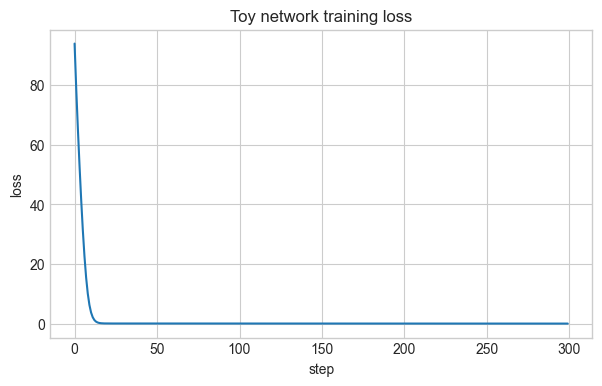

最终预测:
[[ 3.27]
 [ 7.14]
 [11.  ]
 [14.87]]


In [48]:
# ------------------------------
# 这段代码做什么：
# 1. 用 PyTorch 的 model / loss / optimizer 四件套训练 toy 网络
# 2. 让前面讲过的训练模板真正落到代码上
# ------------------------------

X_toy = torch.tensor([[1, 2], [3, 4], [5, 6], [7, 8]], dtype=torch.float32).to(device)
Y_toy = torch.tensor([[3], [7], [11], [15]], dtype=torch.float32).to(device)

model_toy = nn.Sequential(
    nn.Linear(2, 8),
    nn.ReLU(),
    nn.Linear(8, 1),
).to(device)

loss_fn_toy = nn.MSELoss()
optimizer_toy = torch.optim.SGD(model_toy.parameters(), lr=1e-3)

loss_history = []
for _ in range(300):
    # 每一次循环都在重复同一套训练模板。
    pred = model_toy(X_toy)
    loss = loss_fn_toy(pred, Y_toy)

    optimizer_toy.zero_grad()
    loss.backward()
    optimizer_toy.step()
    loss_history.append(float(loss.item()))

plt.figure(figsize=(7, 4))
plt.plot(loss_history)
plt.title('Toy network training loss')
plt.xlabel('step')
plt.ylabel('loss')
plt.show()

print('最终预测:')
print(model_toy(X_toy).detach().cpu().numpy().round(2))

### 这一部分先收束一下

到这里，最小训练模板已经完整落地：

```python
optimizer.zero_grad()
pred = model(X)
loss = loss_fn(pred, Y)
loss.backward()
optimizer.step()
```

把这五行连起来，就是：

- 先清空旧梯度
- 再用当前参数做预测
- 再把预测误差压缩成 loss
- 再把 loss 对参数的梯度算出来
- 最后才真正更新参数

接着看一个承接问题：

> 如果把 `X_toy` 换成真实图像 batch，这个模板还成立吗？

答案是成立的。变化的不是训练主线，而是数据组织方式、模型输入输出形状，以及损失函数的选择。下一部分就把这些变化逐个展开。

# Part 5. 从 toy 问题走到真实视觉任务：FashionMNIST 分类

Part 4 里的模型读的是一个很小的数值矩阵；这一部分把同样的训练主线搬到真实图像分类任务里。

目标不是简单“跑一个 FashionMNIST demo”，而是把一个真实视觉分类 pipeline 的组成部分按顺序讲清楚。

和前面的 toy 例子相比，这里复杂了很多，原因主要有五个：

1. 输入不再是几个手工写下来的数字，而是真实图像数据。
2. 单个样本先是图像张量，训练时又要按 batch 组织。
3. 输出不再是一个回归值，而是 10 类分类打分。
4. 损失函数从回归常用的 `MSELoss` 换成更适合分类的 `CrossEntropyLoss`。
5. 不只看训练集，还要看验证集，判断模型是否真的学会了。

下面按这条顺序往下走：

- 先看单个样本长什么样
- 再看 batch 长什么样
- 再看模型输入输出怎么变化
- 再看分类损失到底在做什么
- 最后进入训练和评估

In [49]:
# ------------------------------
# 这段代码做什么：
# 1. 把真实图像读成 tensor
# 2. 查看单个样本的 shape、dtype、像素范围和标签
# ------------------------------
transform = transforms.ToTensor()
train_tensor = datasets.FashionMNIST(data_root, train=True, download=True, transform=transform)
val_tensor = datasets.FashionMNIST(data_root, train=False, download=True, transform=transform)
class_names = train_tensor.classes

print('训练集大小:', len(train_tensor))
print('验证集大小:', len(val_tensor))
print('类别名:', class_names)

image0, label0 = train_tensor[0]
print('\n单个样本的图像张量 shape:', tuple(image0.shape))
print('单个样本的图像张量 dtype:', image0.dtype)
print('像素值范围: [{:.3f}, {:.3f}]'.format(float(image0.min()), float(image0.max())))
print('标签索引:', int(label0), '=> 类别名:', class_names[label0])

训练集大小: 60000
验证集大小: 10000
类别名: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

单个样本的图像张量 shape: (1, 28, 28)
单个样本的图像张量 dtype: torch.float32
像素值范围: [0.000, 1.000]
标签索引: 9 => 类别名: Ankle boot


### 先把这几行信息讲透

这一小节先看三件事：

1. `ToTensor()` 做了什么
   - 它把原始图像变成 PyTorch tensor。
   - 同时把像素值从 `0~255` 缩放到 `0~1`。
   - 还会补出 channel 维度，所以原来 `28 x 28` 的灰度图，会变成 `1 x 28 x 28`。

2. 标签是什么
   - 标签不是 one-hot 向量，而是一个类别索引，例如 `0~9`。
   - 这和后面 `CrossEntropyLoss` 的输入格式直接相关。

3. 为什么还没开始训练就先看这些
   - 因为后面所有 shape、loss、预测类别，都是围绕这些基本对象展开的。

可以先停一下，问一个很具体的问题：

> 为什么这里的 shape 是 `1 x 28 x 28`，而不是只写成 `28 x 28`？

这个额外的 channel 维度，在后面讲 CNN 时会一直保留下来。

/var/folders/78/32dy907n0l7dwfg058c07mh40000gn/T/ipykernel_47922/1189860154.py:13: UserWarning: Glyph 21333 (\N{CJK UNIFIED IDEOGRAPH-5355}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/78/32dy907n0l7dwfg058c07mh40000gn/T/ipykernel_47922/1189860154.py:13: UserWarning: Glyph 20010 (\N{CJK UNIFIED IDEOGRAPH-4E2A}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/78/32dy907n0l7dwfg058c07mh40000gn/T/ipykernel_47922/1189860154.py:13: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/78/32dy907n0l7dwfg058c07mh40000gn/T/ipykernel_47922/1189860154.py:13: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/78/32dy907n0l7dwfg058c07mh40000gn/T/ipykernel_47922/1189860154.py:13: UserWarning: Glyph 22312 (\N{CJK UNIFIED IDEOGRAPH-5728}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/78/32dy907n0l7dwfg058c07mh40000gn/T/i

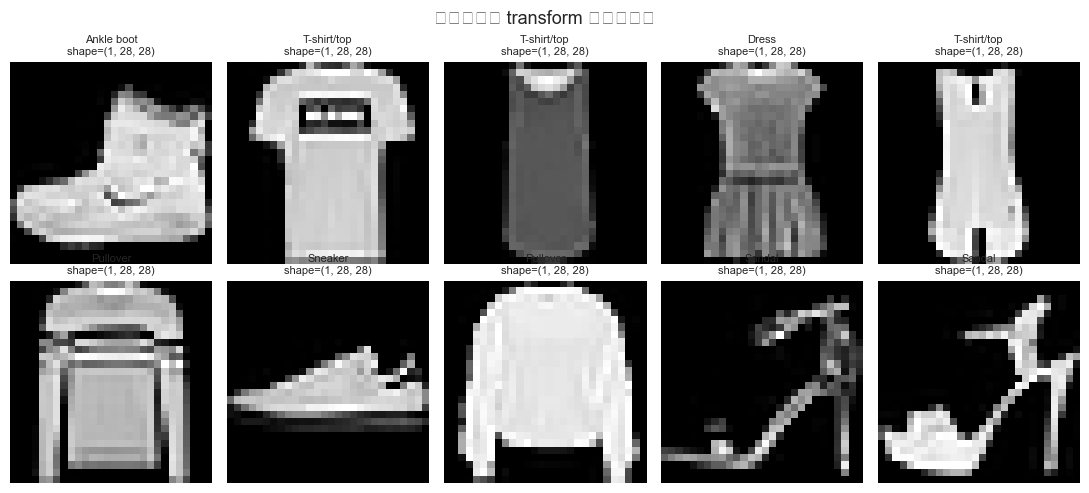

In [50]:
# ------------------------------
# 这段代码做什么：
# 1. 可视化 transform 之后的单个样本
# 2. 把图像内容和张量 shape 放在一起看
# ------------------------------
fig, axes = plt.subplots(2, 5, figsize=(11, 5))
for ax, idx in zip(axes.flat, range(10)):
    image, label = train_tensor[idx]
    ax.imshow(image.squeeze(0), cmap='gray')
    ax.set_title(f'{class_names[label]}\nshape={tuple(image.shape)}', fontsize=8)
    ax.axis('off')
plt.suptitle('单个样本在 transform 之后的样子', fontsize=13)
plt.tight_layout()
plt.show()

### 为什么还需要 `Dataset` 和 `DataLoader`

前面 toy 例子里，直接把一个小矩阵 `X` 喂给模型就结束了。

但真实视觉任务里，这样做不现实：

- 数据量太大，不可能一次性全塞进模型。
- 训练时通常需要随机打乱样本。
- 需要按 batch 读取，才能兼顾显存和训练效率。
- 训练集和验证集的使用方式也不同。

所以通常会这样组织：

- `Dataset`：定义“第 `i` 个样本怎么取”。
- `DataLoader`：定义“如何按 batch 取样、是否打乱、一次取多少”。

可以顺着上一部分继续想：

> 单个样本已经知道长什么样了，那么一批样本进入模型之前会被组织成什么形状？

下面这格代码就是把“单个样本”扩展成“一个 batch”。

In [51]:
# ------------------------------
# 这段代码做什么：
# 1. 构造 Dataset / DataLoader
# 2. 查看一个 batch 在进入模型前是如何组织的
# ------------------------------
# 为了课堂演示速度，这里只取一个较小子集
train_subset = Subset(train_tensor, list(range(4096)))
val_subset = Subset(val_tensor, list(range(1024)))

train_loader = DataLoader(train_subset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=256, shuffle=False)

images, labels = next(iter(train_loader))
print('一个 batch 的图像 shape:', tuple(images.shape))
print('一个 batch 的标签 shape:', tuple(labels.shape))
print('这个 batch 的像素值范围: [{:.3f}, {:.3f}]'.format(float(images.min()), float(images.max())))
print('前 8 个标签索引:', labels[:8].tolist())
print('前 8 个标签类别:', [class_names[int(y)] for y in labels[:8]])

一个 batch 的图像 shape: (128, 1, 28, 28)
一个 batch 的标签 shape: (128,)
这个 batch 的像素值范围: [0.000, 1.000]
前 8 个标签索引: [9, 8, 4, 1, 5, 5, 2, 0]
前 8 个标签类别: ['Ankle boot', 'Bag', 'Coat', 'Trouser', 'Sandal', 'Sandal', 'Pullover', 'T-shirt/top']


/var/folders/78/32dy907n0l7dwfg058c07mh40000gn/T/ipykernel_47922/3294397933.py:12: UserWarning: Glyph 19968 (\N{CJK UNIFIED IDEOGRAPH-4E00}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/78/32dy907n0l7dwfg058c07mh40000gn/T/ipykernel_47922/3294397933.py:12: UserWarning: Glyph 20010 (\N{CJK UNIFIED IDEOGRAPH-4E2A}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/78/32dy907n0l7dwfg058c07mh40000gn/T/ipykernel_47922/3294397933.py:12: UserWarning: Glyph 37324 (\N{CJK UNIFIED IDEOGRAPH-91CC}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/78/32dy907n0l7dwfg058c07mh40000gn/T/ipykernel_47922/3294397933.py:12: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/78/32dy907n0l7dwfg058c07mh40000gn/T/ipykernel_47922/3294397933.py:12: UserWarning: Glyph 21069 (\N{CJK UNIFIED IDEOGRAPH-524D}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/78/32dy907n0l7dwfg058c07mh40000gn/T/i

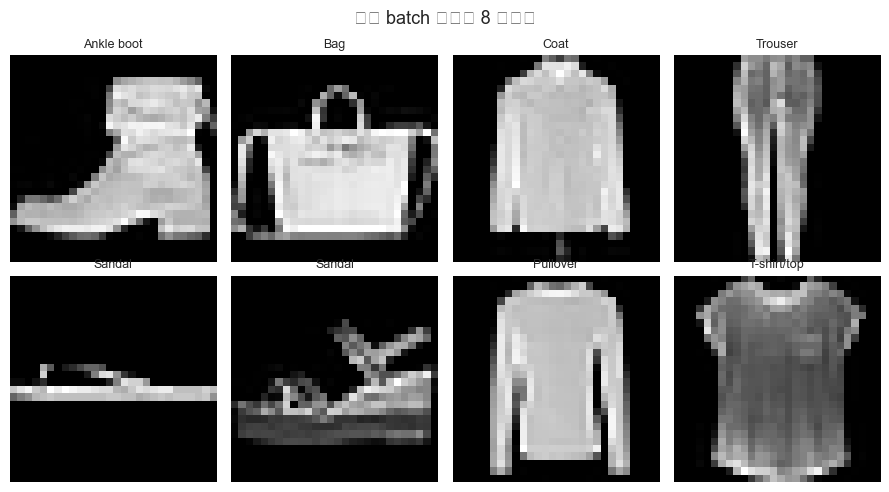

In [52]:
# ------------------------------
# 这段代码做什么：
# 1. 把一个 batch 里的若干图像直接可视化
# 2. 对照前一格输出理解 batch 中的数据内容
# ------------------------------
fig, axes = plt.subplots(2, 4, figsize=(9, 5))
for ax, image, label in zip(axes.flat, images[:8], labels[:8]):
    ax.imshow(image.squeeze(0), cmap='gray')
    ax.set_title(class_names[int(label)], fontsize=9)
    ax.axis('off')
plt.suptitle('一个 batch 里的前 8 张图像', fontsize=13)
plt.tight_layout()
plt.show()

### 从 batch 到模型：输入和输出如何变化

这一小节是 Part 1 的数据形状和 Part 4 的模型接口第一次真正接起来的地方。

现在模型拿到的输入，不再是单张图像，而是一个四维张量：

- 输入 shape：`[B, 1, 28, 28]`
- 这里 `B` 是 batch size，`1` 是通道数，`28 x 28` 是图像尺寸

但这里故意先用一个 **MLP** 做分类，所以第一步要把图像展平：

- `Flatten` 之后：`[B, 784]`

然后网络会输出：

- 输出 shape：`[B, 10]`

这里的 `10` 对应 10 个类别。注意：

- 这 10 个数不是概率。
- 它们叫 **logits**，是模型对每个类别给出的原始打分。
- 预测时通常取 `argmax`。
- 训练时把 logits 直接喂给 `CrossEntropyLoss`。

可以先判断一下：

> 如果输出的是 `[B, 10]`，为什么标签不是 `[B, 10]` 的 one-hot，而是 `[B]` 的类别索引？

下一小节就围绕这个问题展开。

In [53]:
# ------------------------------
# 这段代码做什么：
# 1. 定义一个最简单的图像 MLP 分类器
# 2. 配好分类损失函数和优化器
# 3. 对应“模型 / 损失 / 优化器”三个角色
# ------------------------------
class FlatFashionMNIST(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 256)
        self.act = nn.ReLU()
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x, return_intermediates=False):
        x_flat = self.flatten(x)      # [B, 1, 28, 28] -> [B, 784]
        hidden = self.act(self.fc1(x_flat))
        logits = self.fc2(hidden)     # 10 类原始打分
        if return_intermediates:
            return x_flat, hidden, logits
        return logits

model = FlatFashionMNIST().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

num_params = sum(p.numel() for p in model.parameters())
print('模型总参数量:', num_params)

模型总参数量: 203530


In [54]:
# ------------------------------
# 这段代码做什么：
# 1. 追踪一个 batch 进入模型后的 shape 变化
# 2. 观察 logits 和 top-k 预测是怎么得到的
# ------------------------------
sample_x = images[:4].to(device)
sample_y = labels[:4].to(device)

# 这里只做观察，不更新参数，所以放在 no_grad 环境里。
with torch.no_grad():
    x_flat, hidden, logits = model(sample_x, return_intermediates=True)
    probs = torch.softmax(logits, dim=1)

print('原始 batch 输入 shape:', tuple(sample_x.shape))
print('Flatten 之后 shape:', tuple(x_flat.shape))
print('隐藏层表示 shape:', tuple(hidden.shape))
print('logits shape:', tuple(logits.shape))

print('\n第一个样本的真实类别:', int(sample_y[0]), class_names[int(sample_y[0])])
print('第一个样本的 logits 前 5 维:', logits[0, :5].detach().cpu().numpy().round(3))

top_probs, top_idx = torch.topk(probs[0], k=3)
print('\n第一个样本 top-3 预测:')
for p, idx in zip(top_probs.cpu().numpy(), top_idx.cpu().numpy()):
    print(f'  {class_names[int(idx)]:>12s}: prob={p:.3f}')

原始 batch 输入 shape: (4, 1, 28, 28)
Flatten 之后 shape: (4, 784)
隐藏层表示 shape: (4, 256)
logits shape: (4, 10)

第一个样本的真实类别: 9 Ankle boot
第一个样本的 logits 前 5 维: [-0.044 -0.093 -0.098 -0.122 -0.192]

第一个样本 top-3 预测:
           Bag: prob=0.123
    Ankle boot: prob=0.113
       Sneaker: prob=0.109


### 为什么这里用 `CrossEntropyLoss`

先把“回归损失”和“分类损失”的区别分开。

前面的 toy 例子使用 `MSELoss`，是因为目标是一个连续数值；此时关心的是：

- 预测值和目标值差了多少
- 差距缩小以后，loss 是否下降

但到了 FashionMNIST，任务已经变成 **10 类单标签分类**。这时目标不再是“数值接近”，而是：

- 真实类别的分数更高
- 错误类别的分数更低

可以先想一个问题：

> 如果把类别 `7` 当成一个回归目标，那么“预测成 6.8”是否真的比“预测成 2.1”更合理？

在分类任务里，这种“数值上更接近”其实没有意义，因为类别编号只是索引，不代表连续距离。

所以两类损失关注的对象不同：

- `MSELoss`：关注预测值和目标值的数值差距，适合房价、温度、坐标等连续量。
- `CrossEntropyLoss`：关注真实类别对应的概率是否足够高，适合单标签多分类。

`CrossEntropyLoss` 在 PyTorch 里的输入格式是：

- 输入：`[B, C]` 形状的 logits
- 标签：`[B]` 形状的类别索引

它内部做的事情可以粗略理解为：

1. 先把 logits 变成一个概率分布（`softmax`）
2. 再看真实类别对应的概率是不是足够高
3. 如果真实类别概率很低，loss 就会很大

所以它的作用不是简单判断“猜对还是猜错”，而是在用一个可微分的方式，把真实类别的分数持续往上推。

> 很重要的一点：**把 logits 直接交给 `CrossEntropyLoss` 就行，不要先手动做 softmax。**

In [55]:
# ------------------------------
# 这段代码做什么：
# 1. 用单个样本手动验证 CrossEntropyLoss 的含义
# 2. 对照 logits -> softmax -> 真实类别概率 -> loss 的关系
# ------------------------------
one_x = images[:1].to(device)
one_y = labels[:1].to(device)

# 先拿到模型对单个样本输出的 logits 和 softmax 概率。
with torch.no_grad():
    one_logits = model(one_x)
    one_probs = torch.softmax(one_logits, dim=1)

true_cls = int(one_y.item())
ce_value = loss_fn(one_logits, one_y).item()
manual_value = float((-torch.log_softmax(one_logits, dim=1)[0, true_cls]).item())

print('真实标签索引:', true_cls, '=>', class_names[true_cls])
print('真实类别的预测概率:', float(one_probs[0, true_cls]))
print('CrossEntropyLoss 输出:', ce_value)
print('手动验证 -log softmax(logits)[true_class]:', manual_value)

真实标签索引: 9 => Ankle boot
真实类别的预测概率: 0.11283058673143387
CrossEntropyLoss 输出: 2.181867837905884
手动验证 -log softmax(logits)[true_class]: 2.181867837905884


### 训练一轮和验证一轮，各自在干什么

到这里，数据、模型和损失函数都已经就位，接下来就进入真正的训练流程。

先把训练和验证区分开，不要把两者混在一起。

训练一轮时：

- 取一个 batch
- 前向得到 logits
- 用 loss 衡量预测质量
- 反向传播求梯度
- 用 optimizer 更新参数

验证时：

- 也会前向得到 logits
- 也会计算 loss 和 accuracy
- 但**不会更新参数**
- 一般还会配合 `torch.no_grad()`，减少额外的梯度开销

所以：

- 训练回答的是“模型正在怎么学”
- 验证回答的是“模型学出来以后能不能泛化”

可以先判断一个关键区别：

> 在下面两段函数里，哪一段会出现 `backward()` 和 `step()`，哪一段不会？

In [56]:
# ------------------------------
# 这段代码做什么：
# 1. 分别定义“训练一轮”和“验证一轮”
# 2. 对比 train / eval 两种模式下，哪些步骤相同，哪些不同
# ------------------------------
def train_one_epoch(loader, model, optimizer, loss_fn):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total = 0

    for x, y in loader:
        # 1) 把当前 batch 放到相同设备上。
        x, y = x.to(device), y.to(device)

        # 2) 前向传播，得到分类 logits，并计算当前 batch 的 loss。
        logits = model(x)
        loss = loss_fn(logits, y)

        # 3) 清梯度 -> 反向传播 -> 更新参数。
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # 4) 记录这一轮的平均 loss 和正确率。
        total_loss += float(loss.item()) * len(x)
        total_correct += int((logits.argmax(dim=1) == y).sum().item())
        total += len(x)

    return total_loss / total, total_correct / total

@torch.no_grad()
def evaluate(loader, model, loss_fn):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total = 0

    for x, y in loader:
        # 验证阶段仍然会前向计算，但不会反向传播，也不会更新参数。
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = loss_fn(logits, y)
        total_loss += float(loss.item()) * len(x)
        total_correct += int((logits.argmax(dim=1) == y).sum().item())
        total += len(x)

    return total_loss / total, total_correct / total

In [57]:
# ------------------------------
# 这段代码做什么：
# 1. 运行若干个 epoch
# 2. 记录训练集和验证集上的 loss / accuracy
# ------------------------------
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(2):
    # 每个 epoch 都先训练一遍，再在验证集上检查一次。
    tr_loss, tr_acc = train_one_epoch(train_loader, model, optimizer, loss_fn)
    va_loss, va_acc = evaluate(val_loader, model, loss_fn)

    train_losses.append(tr_loss)
    val_losses.append(va_loss)
    train_accs.append(tr_acc)
    val_accs.append(va_acc)

    print(f'Epoch {epoch + 1}: train_loss={tr_loss:.4f}, train_acc={tr_acc:.3f}, val_loss={va_loss:.4f}, val_acc={va_acc:.3f}')

Epoch 1: train_loss=1.2289, train_acc=0.584, val_loss=0.7891, val_acc=0.702
Epoch 2: train_loss=0.7029, train_acc=0.759, val_loss=0.6696, val_acc=0.742


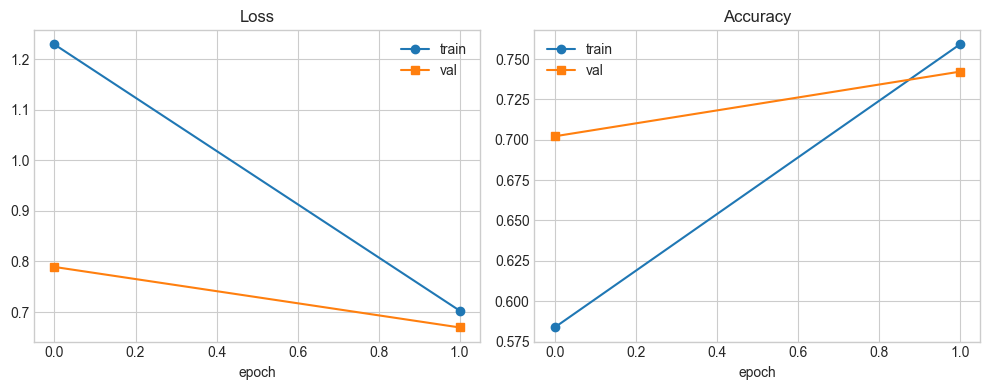

In [58]:
# ------------------------------
# 这段代码做什么：
# 1. 把训练过程里的 loss / accuracy 画出来
# 2. 观察模型是在变好还是已经出现问题
# ------------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(train_losses, marker='o', label='train')
axes[0].plot(val_losses, marker='s', label='val')
axes[0].set_title('Loss')
axes[0].set_xlabel('epoch')
axes[0].legend()
axes[1].plot(train_accs, marker='o', label='train')
axes[1].plot(val_accs, marker='s', label='val')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('epoch')
axes[1].legend()
plt.tight_layout()
plt.show()

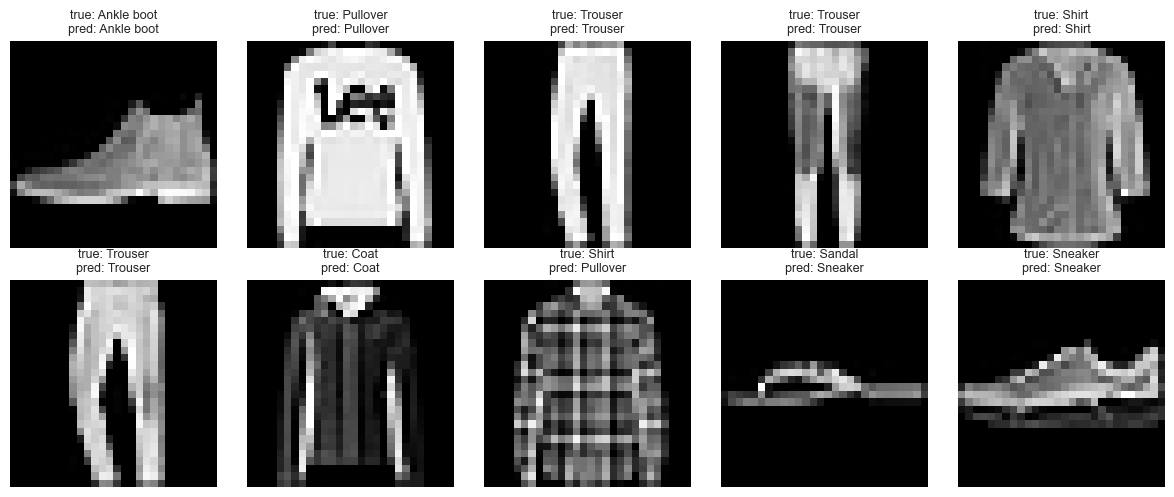

In [59]:
# ------------------------------
# 这段代码做什么：
# 1. 查看若干验证样本的预测结果
# 2. 把“数字指标”重新对应回具体图像
# ------------------------------
# 看几张验证集预测结果
model.eval()
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, idx in zip(axes.flat, range(10)):
    image, label = val_subset[idx]
    with torch.no_grad():
        logits = model(image.unsqueeze(0).to(device))
        pred = int(logits.argmax(dim=1).item())
    ax.imshow(image.squeeze(0), cmap='gray')
    ax.set_title(f'true: {class_names[label]}\npred: {class_names[pred]}', fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

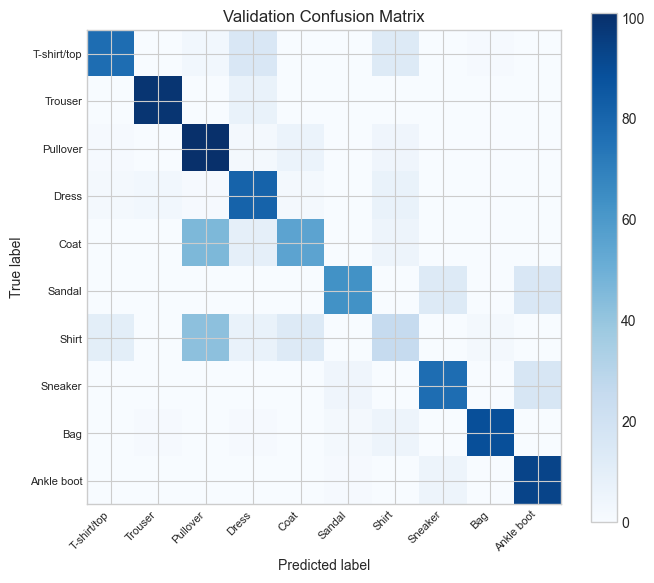

In [60]:
# ------------------------------
# 这段代码做什么：
# 1. 汇总整个验证集的预测情况
# 2. 用 confusion matrix 看模型主要错在什么地方
# ------------------------------
# 用 confusion matrix 看“错在哪里”
a = len(class_names)
cm = torch.zeros(a, a, dtype=torch.int64)

with torch.no_grad():
    # 逐个 batch 汇总真实标签和预测标签，填充混淆矩阵。
    for x, y in val_loader:
        x = x.to(device)
        preds = model(x).argmax(dim=1).cpu()
        for true_label, pred_label in zip(y, preds):
            cm[int(true_label), int(pred_label)] += 1

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm.numpy(), cmap='Blues')
ax.set_xticks(range(a))
ax.set_yticks(range(a))
ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(class_names, fontsize=8)
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_title('Validation Confusion Matrix')
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

### 这一部分真正需要留下来的，不只是“会跑代码”

这部分最重要的理解点有六个：

1. **图像进入模型前，首先是张量**
   - 单张灰度图是 `1 x 28 x 28`
   - 一个 batch 就是 `B x 1 x 28 x 28`

2. **MLP 之所以能接图像，是因为先做了 `Flatten`**
   - 这让模型能工作
   - 但也埋下了空间结构被打散的问题

3. **分类模型输出的是 logits，不是概率**
   - logits 是原始打分
   - 概率只是它们经过 softmax 之后的解释方式

4. **`CrossEntropyLoss` 关心的是：真实类别的分数够不够高**
   - 它不是简单判断“猜对还是猜错”
   - 而是在提供一个连续可微的优化目标

5. **训练集和验证集承担不同职责**
   - 训练集用于更新参数
   - 验证集用于检查泛化

6. **真实视觉任务的代码虽然更长，但训练主线并没有变**
   - 仍然是：前向 -> loss -> backward -> step -> 评估

到这里，一个最基本的图像分类脚本已经能够完整读通。接下来就可以利用这份结果，自然引出 MLP 为什么还不够适合图像。

# Part 6. 为什么下一讲要讲 CNN？

Part 5 已经证明：把图像展平后送进 MLP，流程上是跑得通的。

但只要沿着刚才的 shape 再想一步，就会发现三个问题：

- 参数量会迅速变大。
- 模型看不见局部邻域结构。
- 平移、边缘、纹理等视觉先验没有被显式利用。

所以第二节课自然要引入 CNN。它不是“更复杂的 MLP”，而是“更适合图像结构的模型”。


<img src="images/lesson1_intro/mlp_cnn_transition.png" width="980">

> 讲课提示：第一讲在这里收住，只强调为什么图像任务会自然走向 CNN。ViT / DINO / MAE 如果已有专题课，这里不展开。


# 小结

本节课真正需要留下来的有五句话：

1. 图像就是张量，视觉任务本质上是“从张量到语义”的映射。
2. 神经网络训练的核心闭环是：`预测 -> 计算损失 -> 反向传播 -> 更新参数`。
3. 梯度的作用是把“现在预测得不好”翻译成“每个参数下一步该怎么改”。
4. 一个最基本的视觉分类系统已经包含了数据、模型、损失、优化器和评估。
5. MLP 能帮助理解流程，但要更好地处理图像，下一步需要 CNN。
